In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1. The Dataset

5 features $x_1, \dots, x_5$, 30 samples. The target is generated from **known true weights** plus a little Gaussian noise:

$$y = 2.5x_1 - 1.0x_2 + 0.5x_3 + 3.0x_4 - 2.0x_5 + 4.0 + \varepsilon$$

Knowing the true weights in advance lets us check that gradient descent actually finds them — this is the standard way to sanity-check a from-scratch implementation before trusting it on real data.

In [ ]:
rng = np.random.default_rng(42)

n_samples, n_features = 50, 5

X = rng.uniform(0, 10, size=(n_samples, n_features)).round(2)

true_w = np.array([2.5, -1.0, 0.5, 3.0, -2.0])
true_b = 4.0
noise = rng.normal(0, 1.0, size=n_samples)

y = (X @ true_w + true_b + noise).round(2)

feature_names = [f"x{i+1}" for i in range(n_features)]
df = pd.DataFrame(X, columns=feature_names)
df["y"] = y
df.head()

,x1,x2,x3,x4,x5,y
0,7.03,0.12,9.35,4.07,4.56,29.05
1,0.31,1.96,9.65,1.88,1.35,9.78
2,9.47,4.68,8.62,2.69,6.86,21.43
3,7.81,6.70,1.23,5.58,0.09,33.32
4,1.35,9.84,6.03,8.94,2.43,20.81


In [4]:
def train_test_split(X, y, test_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    n_test = int(len(X) * test_frac)
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_frac=0.2, seed=0)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (24, 5)  Test: (6, 5)


## 3. Feature Standardisation

The 5 features aren't on the same scale, which makes gradient descent slow and finicky (some weights need huge steps, others tiny ones). Standardising each feature to mean 0, std 1 fixes this. We compute mean/std **from the training set only** and apply it to both sets, to avoid leaking test information.

In [ ]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

# Your Code

# print("Feature means (train, standardized):", X_train_s.mean(axis=0), X_train_s.shape)
# print("Feature stds  (train, standardized):", X_train_s.std(axis=0), X_test_s.shape)

Feature means (train, standardized): [-0.  0. -0. -0. -0.] (24, 5)
Feature stds  (train, standardized): [1. 1. 1. 1. 1.] (6, 5)


## 4. Random Weight Initialisation

This is the step your students are practicing: draw random starting weights (and bias) rather than picking anything meaningful.

In [8]:
rng_init = np.random.default_rng()   # separate RNG just for weight init

w = rng_init.normal(loc=0.0, scale=1.0, size=n_features)
b = 0.0

print("Randomly initialised weights:", w, w.shape)
print("Randomly initialised bias:   ", b)

Randomly initialised weights: [-0.0109 -0.3138 -0.3231 -1.7461 -1.9335] (5,)
Randomly initialised bias:    0.0


In [ ]:
def predict(X,w,b):
    pass

def compute_loss(X,w,b,y):
    pass


def gradient(X, y, y_hat):
    
    #Your Code

    #return dL_dw, dL_db


# print(predict(X_train_s, w, b))
# print(gradient(X_train_s, y_train, predict(X_train_s, w, b)))

[ 4.7963  6.5144  4.9733  4.3467  2.3405  0.5036  1.642   4.8152  1.0346
  8.8897 -1.0534  4.748   5.4674  1.9087 -0.5248 -1.5951 -0.0029  4.2632
  4.9178  7.4712  4.779   5.5368  5.6061  1.0795]
(array([-11.2634,   2.2075,  -5.8545, -14.9107,   9.5813]), np.float64(-27.485999999999997))


In [ ]:
rng_init = np.random.default_rng(7)   # separate RNG just for weight init
w, b = rng_init.normal(loc=0.0, scale=1.0, size=n_features), 0.0

print("Randomly initialised weights:", w, w.shape)
print("Randomly initialised bias:   ", b)

history = []
n_epocs = 100
lr = 0.1
for epoch in range(n_epocs):

    # Your Code

# print("Final weights:", w, w.shape)
# print("Final bias:   ", b)


Randomly initialised weights: [ 0.0012  0.2987 -0.2741 -0.8906 -0.4547] (5,)
Randomly initialised bias:    0.0
Final weights: [ 6.8395 -2.3515  1.8446  7.8065 -5.9299] (5,)
Final bias:    17.178749996500635


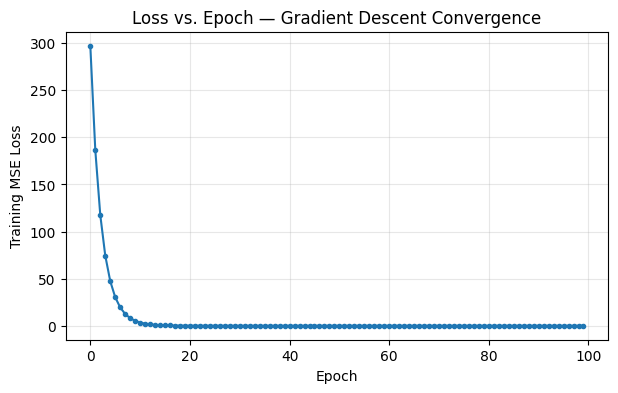

In [33]:
epochs_logged, losses_logged = zip(*history)

plt.figure(figsize=(7, 4))
plt.plot(epochs_logged, losses_logged, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss")
plt.title("Loss vs. Epoch — Gradient Descent Convergence")
plt.grid(alpha=0.3)
plt.show()

## 7. Convert Weights Back to the Original (Unstandardised) Scale

We trained on standardised features, so the learned weights live in "standardised space". To compare against the true weights we generated the data with, convert back:

$$w_{orig} = \frac{w_{std}}{\sigma} \qquad b_{orig} = b_{std} - \sum \frac{w_{std} \cdot \mu}{\sigma}$$

In [ ]:


# comparison = pd.DataFrame({
#     "feature": feature_names,
#     "true_weight": true_w,
#     "learned_weight (gradient descent)": w_orig,
# })
# print(comparison.to_string(index=False))
# print(f"\ntrue_bias = {true_b:.4f}   learned_bias = {b_orig:.4f}")

feature  true_weight  learned_weight (gradient descent)
     x1          2.5                           2.499027
     x2         -1.0                          -1.060505
     x3          0.5                           0.674308
     x4          3.0                           2.977876
     x5         -2.0                          -2.060962

true_bias = 4.0000   learned_bias = 4.0116


## 8. Check Against the Closed-Form Solution (Normal Equation)

Linear regression has an exact analytical solution:

$$\theta^{*} = (X^{T}X)^{-1}X^{T}y$$

If gradient descent worked correctly, its answer should closely match this.

In [ ]:


# closed_form_df = pd.DataFrame({
#     "feature": feature_names + ["bias"],
#     "closed_form_weight": theta_closed_form,
#     "gradient_descent_weight": np.append(w_orig, b_orig),
# })
# print(closed_form_df.to_string(index=False))

feature  closed_form_weight  gradient_descent_weight
     x1            2.499027                 2.499027
     x2           -1.060505                -1.060505
     x3            0.674307                 0.674308
     x4            2.977876                 2.977876
     x5           -2.060962                -2.060962
   bias            4.011612                 4.011610
